

Phase 2: Linear regression



Filtered data (IRRADIATION > 0): 38376 lines


Feature selection



Features (X):
  - IRRADIATION (W/m²)
  - AMBIENT_TEMPERATURE (°C)
  - MODULE_TEMPERATURE (°C)

Target (Y):
  - AC_POWER (W)

Features statistics:
        IRRADIATION  AMBIENT_TEMPERATURE  MODULE_TEMPERATURE
count  68774.000000         68774.000000        68774.000000
mean       0.232305            25.558521           31.244997
std        0.301948             3.361300           12.308283
min        0.000000            20.398505           18.140415
25%        0.000000            22.724491           21.123944
50%        0.031620            24.670178           24.818984
75%        0.454880            27.960429           41.693659
max        1.221652            35.252486           65.545714

Target statistics:
count    68774.000000
mean       307.778375
std        394.394865
min          0.000000
25%          0.000000
50%         41.450000
75%        623.561161
max       1410.950000
Name: AC_

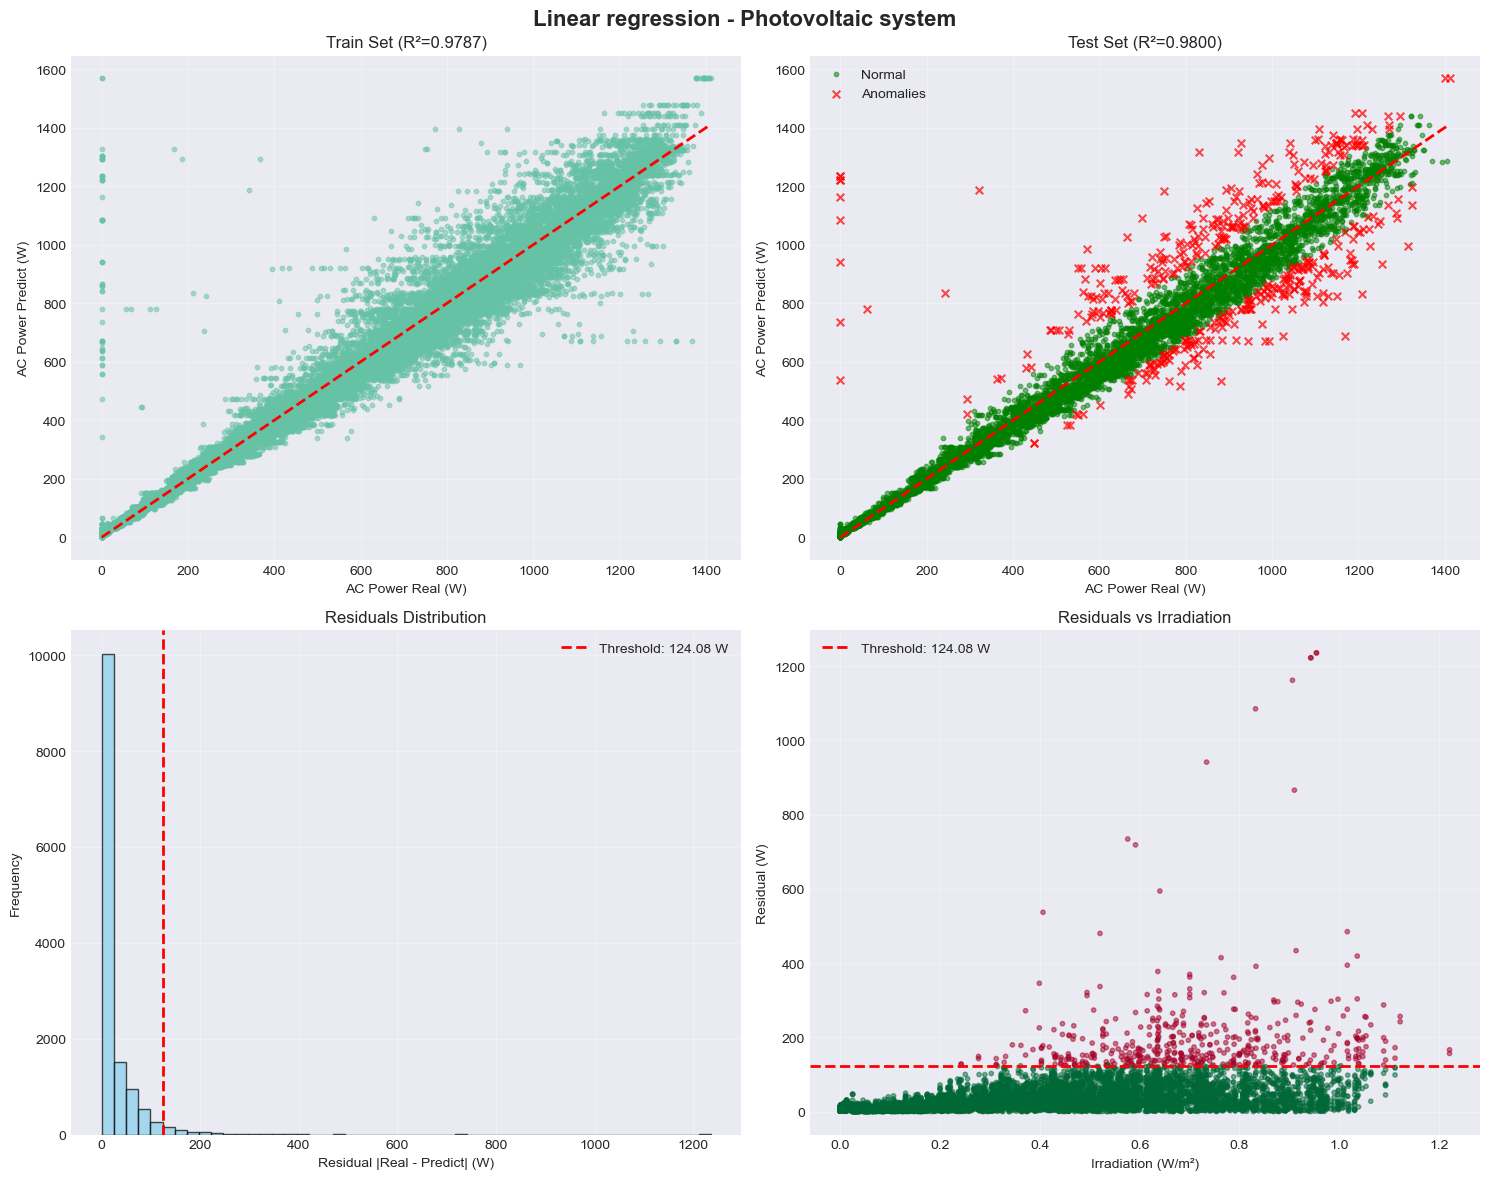

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Graphics configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

print("\n")
print("Phase 2: Linear regression")
print("\n")

df = pd.read_csv(r"C:\Users\lisee\Downloads\cleaned_solar_data.csv")

# Filter only for daylight hours (IRRADIATION > 0)
df_day = df[df['IRRADIATION'] > 0].copy()
print(f"\nFiltered data (IRRADIATION > 0): {len(df_day)} lines")

# Feature selection
print("\n")
print("Feature selection")
print("\n")
df_day = df

# Features (X): irradiation, ambient_temperature, module_temperature
X = df_day[['IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE']]

# Target (Y): ac_power
y = df_day['AC_POWER']

print("\nFeatures (X):")
print(f"  - IRRADIATION (W/m²)")
print(f"  - AMBIENT_TEMPERATURE (°C)")
print(f"  - MODULE_TEMPERATURE (°C)")
print(f"\nTarget (Y):")
print(f"  - AC_POWER (W)")

# Descriptive statistics
print("\nFeatures statistics:")
print(X.describe())
print("\nTarget statistics:")
print(y.describe())

# 4. SPLIT TRAIN/TEST
print("\n")
print("Split train/test (80/20)")
print("\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTrain set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

# 5. Model training
print("\n")
print("Linear regression training")
print("\n")

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Display the coefficients
print("\nMODEL EQUATION:")
print(f"AC_POWER = {model.intercept_:.4f}")
print(f"           + {model.coef_[0]:.4f} × IRRADIATION")
print(f"           + {model.coef_[1]:.4f} × AMBIENT_TEMPERATURE")
print(f"           + {model.coef_[2]:.4f} × MODULE_TEMPERATURE")

# Predictions
print("\n")
print("Prediction")
print("\n")

# Predictions on train and test sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Model evaluation
print("\n")
print("Model evaluation")
print("\n")

# Metrics on the train set
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

print("\nTrain set:")
print(f"  R² Score:  {train_r2:.4f}")
print(f"  RMSE:      {train_rmse:.2f} W")
print(f"  MAE:       {train_mae:.2f} W")

# Metrics on the test set
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\nTest set:")
print(f"  R² Score:  {test_r2:.4f}")
print(f"  RMSE:      {test_rmse:.2f} W")
print(f"  MAE:       {test_mae:.2f} W")

# Anomalies detection
print("\n")
print("Anomaly detection")

# Calculate the residuals
residuals = np.abs(y_test - y_test_pred)

# Define the anomaly threshold
threshold = residuals.mean() + 2 * residuals.std()

# Identify anomalies
anomalies = residuals > threshold
n_anomalies = anomalies.sum()
anomaly_percentage = (n_anomalies / len(y_test)) * 100

print(f"\nAnomaly threshold: {threshold:.2f} W")
print(f"Anomalies detected: {n_anomalies} ({anomaly_percentage:.2f}%)")
print(f"\nThese anomalies may indicate:")
print(f"   - Hardware failures")
print(f"   - Panel fouling")
print(f"   - Temporary shading")
print(f"   - PV cell degradation")

# Visualisations
print("\n")
print("Generation of visualizations")

# Create a figure with 3 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Linear regression - Photovoltaic system', fontsize=16, fontweight='bold')

# Predictions vs. Reality (Train)
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5, s=10)
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('AC Power Real (W)', fontsize=10)
axes[0, 0].set_ylabel('AC Power Predict (W)', fontsize=10)
axes[0, 0].set_title(f'Train Set (R²={train_r2:.4f})', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# Predictions vs. Reality (Test) with anomalies
normal_mask = ~anomalies
axes[0, 1].scatter(y_test[normal_mask], y_test_pred[normal_mask],
                   alpha=0.5, s=10, c='green', label='Normal')
axes[0, 1].scatter(y_test[anomalies], y_test_pred[anomalies],
                   alpha=0.7, s=30, c='red', label='Anomalies', marker='x')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('AC Power Real (W)', fontsize=10)
axes[0, 1].set_ylabel('AC Power Predict (W)', fontsize=10)
axes[0, 1].set_title(f'Test Set (R²={test_r2:.4f})', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Distribution of residuals
axes[1, 0].hist(residuals, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.2f} W')
axes[1, 0].set_xlabel('Residual |Real - Predict| (W)', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Residuals Distribution', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Residuals vs. Irradiation
axes[1, 1].scatter(X_test['IRRADIATION'], residuals, alpha=0.5, s=10, c=anomalies, cmap='RdYlGn_r')
axes[1, 1].axhline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.2f} W')
axes[1, 1].set_xlabel('Irradiation (W/m²)', fontsize=10)
axes[1, 1].set_ylabel('Residual (W)', fontsize=10)
axes[1, 1].set_title('Residuals vs Irradiation', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('solar_regression_results.png', dpi=300, bbox_inches='tight')

# Create a DataFrame with the results
results_df = pd.DataFrame({
    'AC_POWER_REAL': y_test.values,
    'AC_POWER_PREDICTED': y_test_pred,
    'RESIDUAL': residuals,
    'IS_ANOMALY': anomalies,
    'IRRADIATION': X_test['IRRADIATION'].values,
    'AMBIENT_TEMPERATURE': X_test['AMBIENT_TEMPERATURE'].values,
    'MODULE_TEMPERATURE': X_test['MODULE_TEMPERATURE'].values
})

results_df.to_csv('solar_regression_predictions_linear_regression.csv', index=False)

# Save the metrics
metrics = {
    'Model': ['Linear Regression'],
    'Train_R2': [train_r2],
    'Train_RMSE': [train_rmse],
    'Train_MAE': [train_mae],
    'Test_R2': [test_r2],
    'Test_RMSE': [test_rmse],
    'Test_MAE': [test_mae],
    'Anomalies': [n_anomalies],
    'Anomaly_Percentage': [anomaly_percentage]
}

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv('solar_regression_metrics_linear_regression.csv', index=False)

plt.show()